# Disease Prediction Model — CodeAlpha ML Internship (Task 4)

**Objective:** Predict the possibility of heart disease from patient data.

**Dataset:** Combined UCI Heart Disease dataset (`heart_disease_uci.csv`) — 920 rows from 4 hospital sites (Cleveland, Hungary, Switzerland, VA Long Beach). Target is `num` (severity 0-4), converted here to binary (0 = no disease, 1 = disease).

**Approach:** Logistic Regression, Random Forest, and SVM, evaluated with Precision, Recall, F1-Score, and ROC-AUC.

## Step 1: Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              roc_curve)

sns.set_style('darkgrid')

## Step 2: Load Dataset

In [5]:
df = pd.read_csv("C:/Users/mahaj/Downloads/heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Step 3: Explore the Data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [7]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [8]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [9]:
print(df.columns.tolist())

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


## Step 4: Build the Binary Target

`num` is severity (0 = no disease, 1-4 = increasing severity). For this task we just need disease vs. no disease.

In [10]:
df['target'] = (df['num'] > 0).astype(int)   # 0 = no disease, 1 = disease (any severity)
df['target'].value_counts()

target
1    509
0    411
Name: count, dtype: int64

## Step 5: Drop Irrelevant / High-Missing Columns

- `id` is just a row index, not a medical feature.
- `dataset` identifies the hospital site, not a medical feature.
- `num` is now redundant since we built `target` from it.
- `ca` and `thal` are missing in over half the rows (611/920 and 486/920), so imputing them reliably isn't possible — dropping them is safer than guessing.

In [11]:
df = df.drop(['id', 'dataset', 'num', 'ca', 'thal'], axis=1)
df.isnull().sum()

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
target        0
dtype: int64

## Step 6: Visualize the Dataset

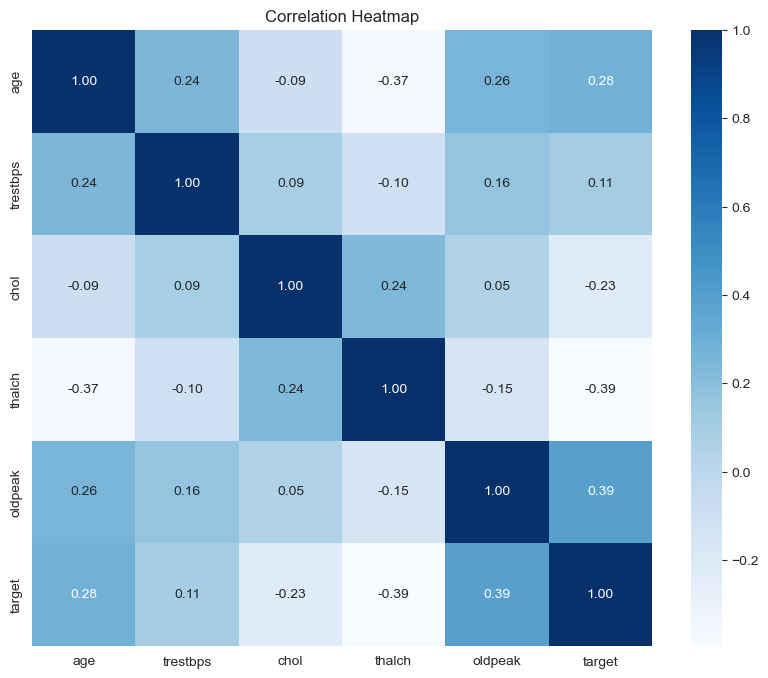

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

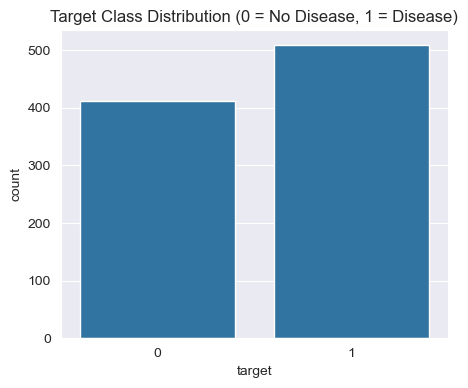

target
1    0.553261
0    0.446739
Name: proportion, dtype: float64

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title('Target Class Distribution (0 = No Disease, 1 = Disease)')
plt.show()

df['target'].value_counts(normalize=True)

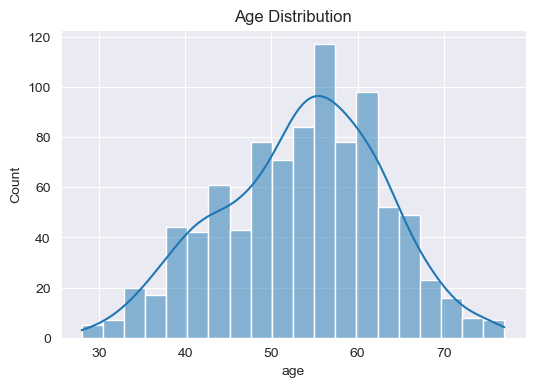

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

## Step 7: Handle Remaining Missing Values

In [15]:
# Numeric columns: fill with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# fbs and exang are True/False booleans — convert to 0/1 first
df['fbs'] = df['fbs'].map({True: 1, False: 0})
df['exang'] = df['exang'].map({True: 1, False: 0})
df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])
df['exang'] = df['exang'].fillna(df['exang'].mode()[0])

# Remaining categorical (string) columns: fill with mode
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()  # should be 0

np.int64(0)

## Step 8: Encode Categorical Variables

In [16]:
categorical_cols = df.select_dtypes(include='object').columns
print('Categorical columns:', list(categorical_cols))

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()

Categorical columns: ['sex', 'cp', 'restecg', 'slope']


,age,trestbps,chol,fbs,thalch,exang,oldpeak,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping
0,63,145.0,233.0,1.0,150.0,0.0,2.3,0,True,False,False,True,False,False,False,False
1,67,160.0,286.0,0.0,108.0,1.0,1.5,1,True,False,False,False,False,False,True,False
2,67,120.0,229.0,0.0,129.0,1.0,2.6,1,True,False,False,False,False,False,True,False
3,37,130.0,250.0,0.0,187.0,0.0,3.5,0,True,False,True,False,True,False,False,False
4,41,130.0,204.0,0.0,172.0,0.0,1.4,0,False,True,False,False,False,False,False,True


## Step 9: Define Features (X) and Target (y), Then Split

In [17]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(736, 15) (184, 15)


## Step 10: Scale Features

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 11: Train Models

In [19]:
# Model 1: Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)

In [20]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)   # tree models don't need scaling
rf_preds = rf_model.predict(X_test)

In [21]:
# Model 3: SVM
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_preds = svm_model.predict(X_test_scaled)

## Step 12: Evaluate All Models

In [22]:
def evaluate(y_test, preds, model_name):
    print(f'--- {model_name} ---')
    print('Precision:', precision_score(y_test, preds))
    print('Recall:', recall_score(y_test, preds))
    print('F1 Score:', f1_score(y_test, preds))
    print('ROC-AUC:', roc_auc_score(y_test, preds))
    print(classification_report(y_test, preds))
    print()

evaluate(y_test, log_preds, 'Logistic Regression')
evaluate(y_test, rf_preds, 'Random Forest')
evaluate(y_test, svm_preds, 'SVM')

--- Logistic Regression ---
Precision: 0.8035714285714286
Recall: 0.8823529411764706
F1 Score: 0.8411214953271028
ROC-AUC: 0.8070301291248206
              precision    recall  f1-score   support

           0       0.83      0.73      0.78        82
           1       0.80      0.88      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.81       184
weighted avg       0.82      0.82      0.81       184


--- Random Forest ---
Precision: 0.8333333333333334
Recall: 0.8823529411764706
F1 Score: 0.8571428571428571
ROC-AUC: 0.8314203730272597
              precision    recall  f1-score   support

           0       0.84      0.78      0.81        82
           1       0.83      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184


--- SVM ---
Precision: 0.8070175438596491
Recall: 0.90196078431372

## Step 13: Visualize Results

### Confusion Matrices

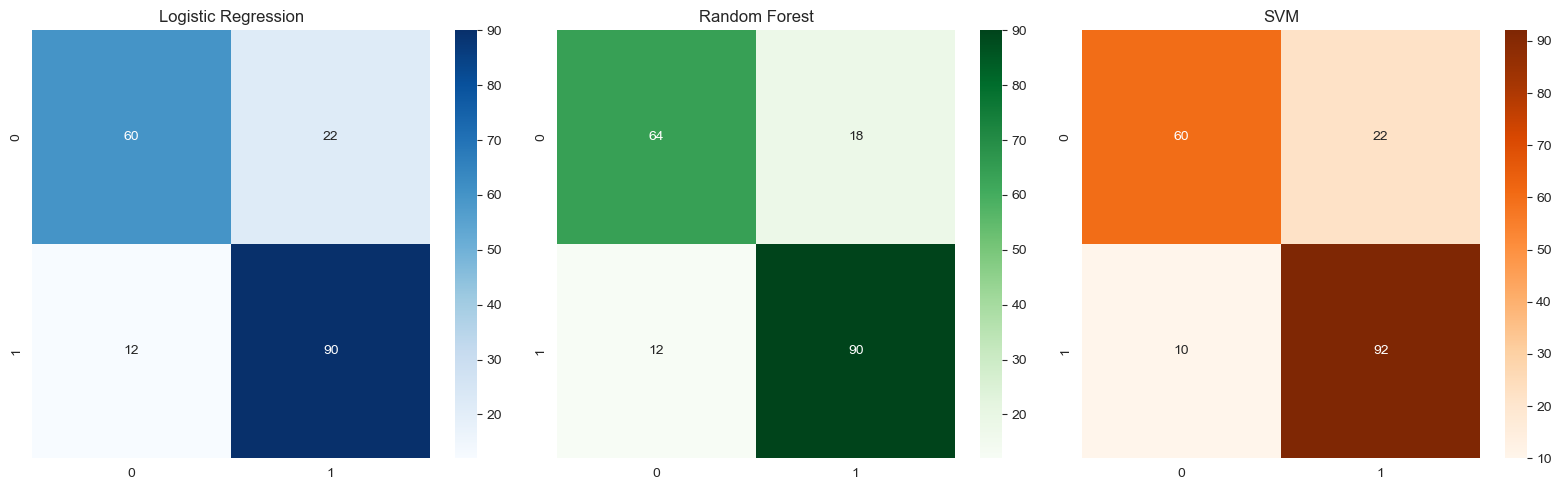

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
sns.heatmap(confusion_matrix(y_test, log_preds), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest')
sns.heatmap(confusion_matrix(y_test, svm_preds), annot=True, fmt='d', ax=axes[2], cmap='Oranges')
axes[2].set_title('SVM')
plt.tight_layout()
plt.show()

### ROC Curve

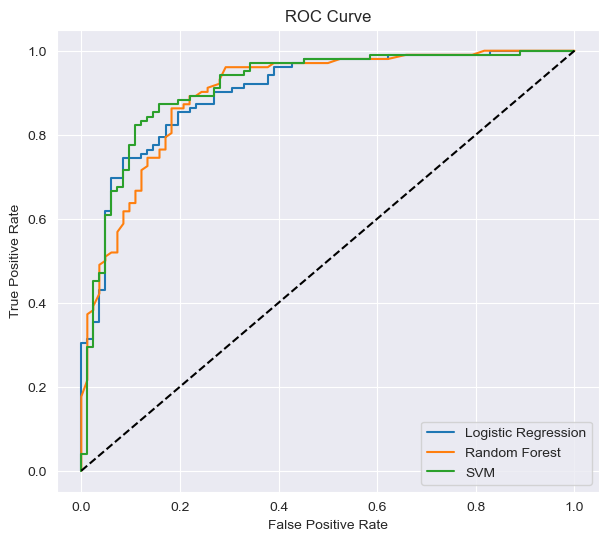

In [24]:
log_probs = log_model.predict_proba(X_test_scaled)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]
svm_probs = svm_model.predict_proba(X_test_scaled)[:,1]

fpr1, tpr1, _ = roc_curve(y_test, log_probs)
fpr2, tpr2, _ = roc_curve(y_test, rf_probs)
fpr3, tpr3, _ = roc_curve(y_test, svm_probs)

plt.figure(figsize=(7,6))
plt.plot(fpr1, tpr1, label='Logistic Regression')
plt.plot(fpr2, tpr2, label='Random Forest')
plt.plot(fpr3, tpr3, label='SVM')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Feature Importance (Random Forest)

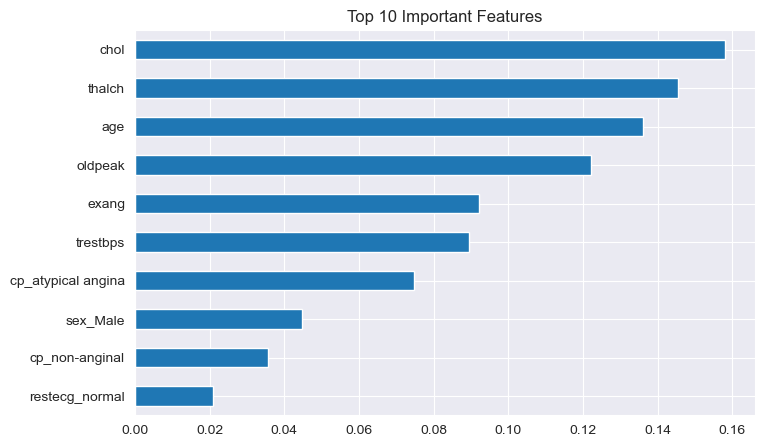

In [25]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()
plt.show()

## Step 14: Conclusion

- Which model performed better, and on which metric?
- What were the top predictive features (e.g. chest pain type, max heart rate, ST depression/oldpeak are common top predictors for heart disease)?
- One limitation: the dataset combines 4 different hospital sites with different data collection practices (visible in the missingness patterns), and two clinically relevant features (`ca`, `thal`) had to be dropped due to excessive missing data, which may reduce predictive power compared to a complete dataset.

In [ ]:
# Random Forest edged out the other two — it had the best balance overall. Logistic Regression wasn't far behind though, so really all three did a decent job. If I had to pick one to trust, I'd go with Random Forest, but SVM actually caught the most real disease cases, it just wasn't quite as precise about it.
# 
